# 📓 POC: Pipeline de Linear Probing (DINOv2 + Roboflow)

Este notebook demonstra o fluxo completo da Prova de Conceito (POC) de classificação de calçadas.
Ele orquestra o download automático dos dados do Roboflow, a extração das features usando o modelo DINOv2 original (via Hugging Face) e, finalmente, treina e avalia a camada linear (Regressão Logística) para obtermos as métricas e a matriz de confusão.

## 1. Configuração e Imports

In [9]:
import os
# Muda o diretório atual para a raiz do projeto (importante no Jupyter)
if os.getcwd().endswith("notebooks"):
    os.chdir("..")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

## 2. Ingestão de Dados

Vamos invocar nosso script de ingestão. Ele verifica o seu arquivo `.env` (buscando pelas chaves `ROBOFLOW_API_KEY`, `ROBOFLOW_WORKSPACE_NAME`, etc) e baixa as imagens divididas em *train*, *valid* e *test* diretamente para a pasta `data/raw/`.

In [2]:
!python scripts/ingestao/download_roboflow.py

Conectando ao Roboflow (Workspace: felipe-dos-reis-garcez, Projeto: apx2-bzsou, Versão: 2)...
loading Roboflow workspace...
loading Roboflow project...
Baixando o dataset na versão 2 e formato 'coco'...

Extracting Dataset Version Zip to /home/carlos/APx-2026.2-Task2-Producao-de-dad
✅ DATASET BAIXADO COM SUCESSO!
📁 Local: /home/carlos/APx-2026.2-Task2-Producao-de-dados-de-qualidade-e-tipologia-de-calcadas/notebooks/data/raw/apx2-bzsou-v2


## 3. Extração de Features (DINOv2)

O Linear Probing consiste em **congelar** o modelo visual principal e treinar apenas uma camada final rápida. 

Abaixo, rodamos o script de extração. Ele usa a biblioteca `transformers` para baixar/carregar o modelo base do DINOv2, processar cada imagem gerando um vetor (array) representativo (CLS token), e salva tudo em `data/processed/` (.npy).

In [10]:
!python scripts/transformacao/extract_features.py

Iniciando extração. Usando dispositivo: cpu
Baixando/Carregando modelo 'projectsidewalk/sidewalk-validator-ai-surfaceproblem' do HuggingFace...
Loading weights: 100%|█████████████████████| 439/439 [00:00<00:00, 4017.21it/s]
[transformers] Dinov2Model LOAD REPORT from: projectsidewalk/sidewalk-validator-ai-surfaceproblem
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Extraindo features em 'train'...
100%|████████████████████████████████████████| 313/313 [06:23<00:00,  1.23s/it]
[train] Salvo: 312 amostras, cada uma com vetor de tamanho 1024
Extraindo features em 'valid'...
100%|██████████████████████████████████████████| 89/89 [01:46<00:00,  1.19s/it]
[valid] Salvo: 89 amostras, cada uma com vetor de tamanho 1024
Extraindo features em 'test'...
100%|███████████████████

## 4. Modelagem: Treinamento do Linear Probe

Com as features (vetores) e labels (0 ou 1) devidamente extraídos, nós carregamos os arquivos do disco para treinar nossa Regressão Logística em tempo recorde.

In [11]:
DATA_DIR = "data/processed/apx2-bzsou-v2"

print("Carregando features extraídas...")
X_train = np.load(os.path.join(DATA_DIR, "train_features.npy"))
y_train = np.load(os.path.join(DATA_DIR, "train_labels.npy"))

X_valid = np.load(os.path.join(DATA_DIR, "valid_features.npy"))
y_valid = np.load(os.path.join(DATA_DIR, "valid_labels.npy"))

X_test = np.load(os.path.join(DATA_DIR, "test_features.npy"))
y_test = np.load(os.path.join(DATA_DIR, "test_labels.npy"))

print(f"Dimensões de Treino: {X_train.shape[0]} amostras com {X_train.shape[1]} features (variáveis).")
print(f"Distribuição no Treino -> Adequada: {np.sum(y_train==0)} | Inadequada: {np.sum(y_train==1)} | Sem calçada: {np.sum(y_train==2)} | Não identificável: {np.sum(y_train==3)}")


Carregando features extraídas...
Dimensões de Treino: 312 amostras com 1024 features (variáveis).
Distribuição no Treino -> Adequada: 143 | Inadequada: 82 | Sem calçada: 33 | Não identificável: 54


In [12]:
# Configurando e treinando o classificador
# O class_weight='balanced' ajuda caso tenhamos classes desbalanceadas
clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)

print("✅ Treinamento concluído!")

✅ Treinamento concluído!


## 5. Avaliação e Visualização de Resultados

Vamos agora visualizar como o modelo se saiu através das métricas (F1-score, Precision, Recall) e renderizar a Matriz de Confusão.

In [13]:
def evaluate(model, X, y, split_name):
    predictions = model.predict(X)
    acc = accuracy_score(y, predictions)
    print(f"--- Resultados no conjunto de {split_name.upper()} ---")
    print(f"Acurácia Geral: {acc:.4f}\n")
    print("Relatório de Classificação:")
    print(classification_report(y, predictions, labels=[0, 1, 2, 3], target_names=["Adequada (0)", "Inadequada (1)", "Sem calçada (2)", "Não identificável (3)"], zero_division=0))
    return confusion_matrix(y, predictions, labels=[0, 1, 2, 3])

print("AVALIAÇÃO NA VALIDAÇÃO:\n")
cm_valid = evaluate(clf, X_valid, y_valid, "Validação")
print("="*60 + "\n")
print("AVALIAÇÃO NO TESTE:\n")
cm_test = evaluate(clf, X_test, y_test, "Teste")

AVALIAÇÃO NA VALIDAÇÃO:

--- Resultados no conjunto de VALIDAÇÃO ---
Acurácia Geral: 0.6292

Relatório de Classificação:
                       precision    recall  f1-score   support

         Adequada (0)       0.65      0.65      0.65        40
       Inadequada (1)       0.55      0.52      0.53        23
      Sem calçada (2)       0.73      0.80      0.76        10
Não identificável (3)       0.62      0.62      0.62        16

             accuracy                           0.63        89
            macro avg       0.64      0.65      0.64        89
         weighted avg       0.63      0.63      0.63        89


AVALIAÇÃO NO TESTE:

--- Resultados no conjunto de TESTE ---
Acurácia Geral: 0.6444

Relatório de Classificação:
                       precision    recall  f1-score   support

         Adequada (0)       0.79      0.55      0.65        20
       Inadequada (1)       0.36      0.56      0.43         9
      Sem calçada (2)       1.00      0.70      0.82        10
Não i

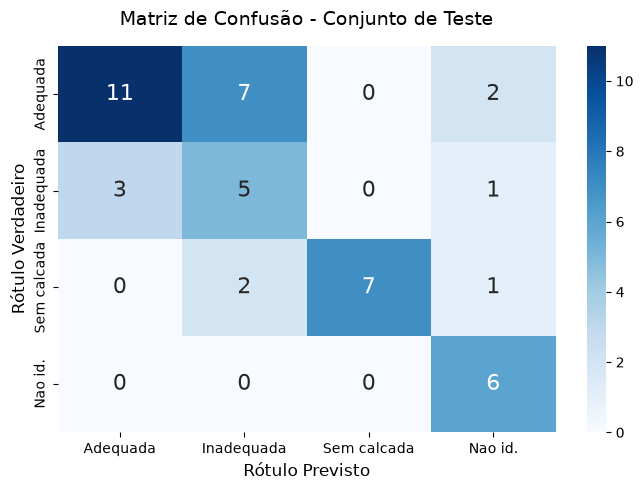

In [14]:
# Visualização da Matriz de Confusão (Teste)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Adequada", "Inadequada", "Sem calcada", "Nao id."], 
            yticklabels=["Adequada", "Inadequada", "Sem calcada", "Nao id."],
            annot_kws={"size": 16})
plt.title('Matriz de Confusão - Conjunto de Teste', fontsize=14, pad=15)
plt.ylabel('Rótulo Verdadeiro', fontsize=12)
plt.xlabel('Rótulo Previsto', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Inferência no Mundo Real (Novas Imagens)

Para testar se o modelo aprendeu bem, vamos simular o uso real. Vamos carregar **10 imagens aleatórias** que o script `extracao-street-view.py` acabou de baixar da rua, extrair as features pelo DINOv2 na hora, passar pela nossa Regressão Logística (`clf`) e plotar os resultados na tela!

Carregando modelo DINOv2 para inferência nas 10 imagens...


Loading weights: 100%|██████████| 439/439 [00:00<00:00, 7452.36it/s]
[transformers] Dinov2Model LOAD REPORT from: projectsidewalk/sidewalk-validator-ai-surfaceproblem
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Realizando inferência...


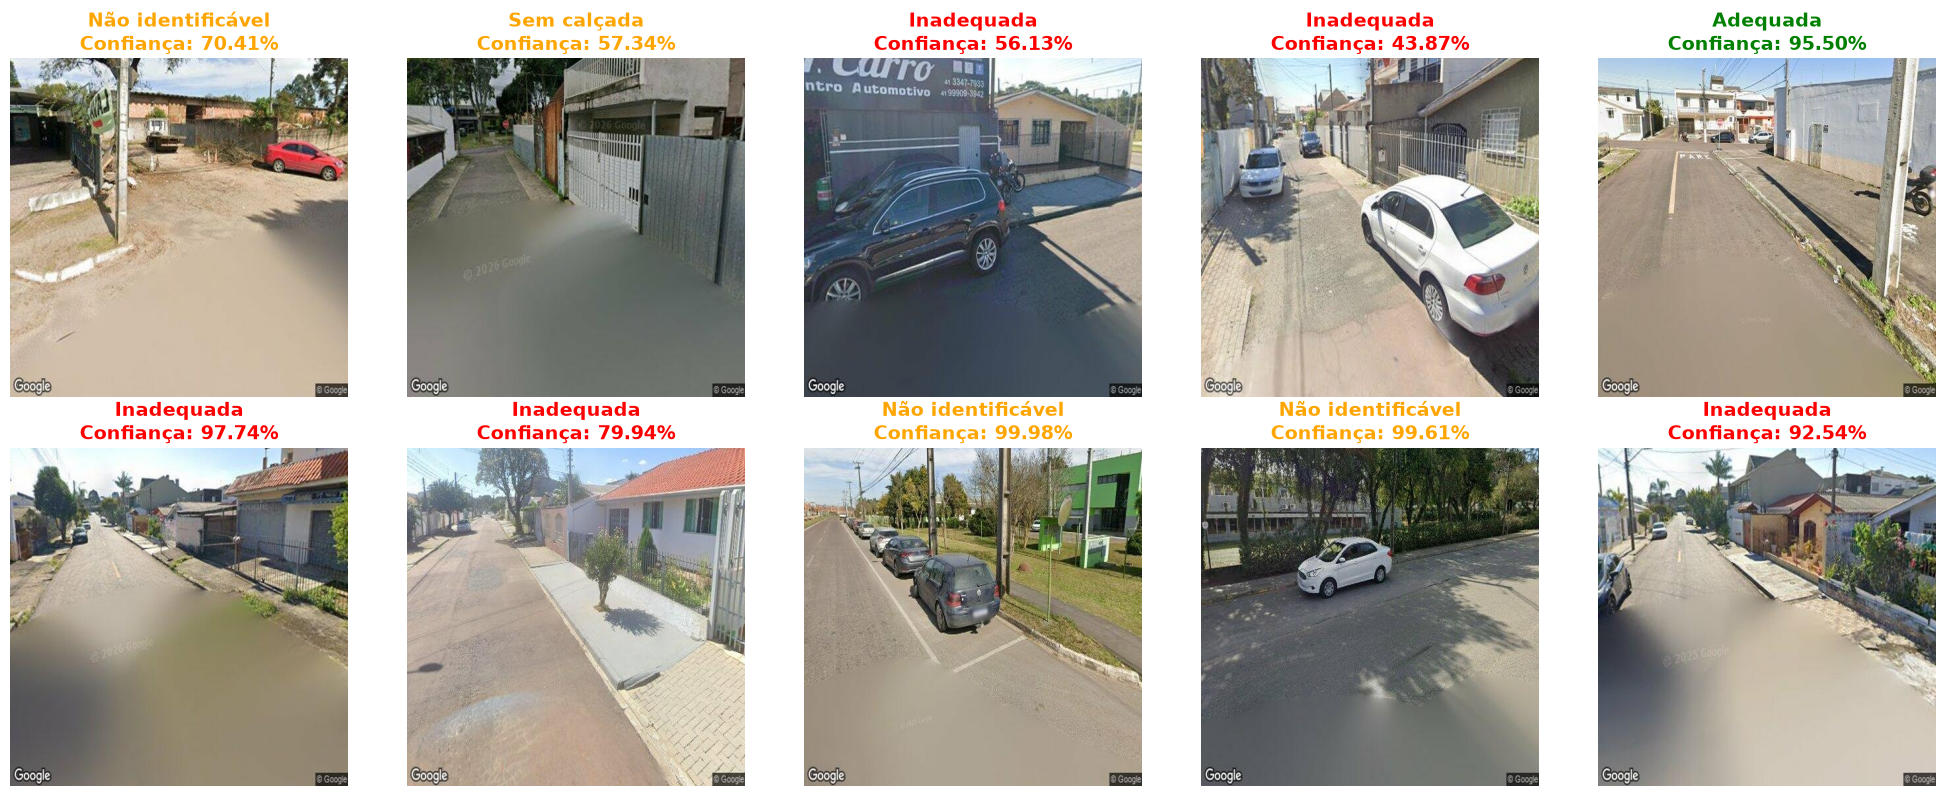

In [16]:
import os
import random
from PIL import Image
import torch
from transformers import AutoImageProcessor, AutoModel

NEW_DATA_DIR = "data/raw/dataset_calcadas_cic" # se movido, ou apenas dataset_calcadas_cic
if not os.path.exists(NEW_DATA_DIR):
    NEW_DATA_DIR = "dataset_calcadas_cic" # Na raiz do projeto

all_images = [f for f in os.listdir(NEW_DATA_DIR) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
sample_images = random.sample(all_images, min(10, len(all_images)))

print(f"Carregando modelo DINOv2 para inferência nas {len(sample_images)} imagens...")
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = AutoImageProcessor.from_pretrained("projectsidewalk/sidewalk-validator-ai-surfaceproblem")
model = AutoModel.from_pretrained("projectsidewalk/sidewalk-validator-ai-surfaceproblem").to(device)
model.eval()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

class_names = {0: "Adequada", 1: "Inadequada", 2: "Sem calçada", 3: "Não identificável"}

print("Realizando inferência...")
for i, img_name in enumerate(sample_images):
    img_path = os.path.join(NEW_DATA_DIR, img_name)
    image = Image.open(img_path).convert("RGB")
    
    # 1. Extração de Features (DINOv2)
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    cls_token = outputs.last_hidden_state[:, 0, :].cpu().numpy()
    
    # 2. Previsão da Regressão Logística
    pred = clf.predict(cls_token)[0]
    prob = clf.predict_proba(cls_token)[0][list(clf.classes_).index(pred)]
    
    # 3. Plotagem
    ax = axes[i]
    ax.imshow(image)
    ax.axis("off")
    color = "green" if pred == 0 else "red" if pred == 1 else "orange"
    ax.set_title(f"{class_names[pred]}\nConfiança: {prob:.2%}", color=color, fontsize=14, weight="bold")

plt.tight_layout()
plt.show()